In [5]:
import cv2
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")
import keras

# Importing image dataset from directory

In [6]:
import tensorflow as tf

IMG_SIZE = 200
BATCH_SIZE = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    r"archive (5)\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    r"archive (5)\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\PAWAN\mega project\Plants Disease Dectection\archive (5)\test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Found 33 files belonging to 1 classes.


In [3]:
len(train_ds),len(val_ds),len(test_ds)

(4394, 1099, 3)

In [4]:
loss = "sparse_categorical_crossentropy"

In [5]:
class_names = train_ds.class_names
print(class_names[:5])

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [6]:
for class_name in class_names:
    count = len(os.listdir(r"archive (5)\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train\{}".format(class_name)))
    print(f"{class_name}: {count}")

Apple___Apple_scab: 2016
Apple___Black_rot: 1987
Apple___Cedar_apple_rust: 1760
Apple___healthy: 2008
Blueberry___healthy: 1816
Cherry_(including_sour)___Powdery_mildew: 1683
Cherry_(including_sour)___healthy: 1826
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642
Corn_(maize)___Common_rust_: 1907
Corn_(maize)___Northern_Leaf_Blight: 1908
Corn_(maize)___healthy: 1859
Grape___Black_rot: 1888
Grape___Esca_(Black_Measles): 1920
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722
Grape___healthy: 1692
Orange___Haunglongbing_(Citrus_greening): 2010
Peach___Bacterial_spot: 1838
Peach___healthy: 1728
Pepper,_bell___Bacterial_spot: 1913
Pepper,_bell___healthy: 1988
Potato___Early_blight: 1939
Potato___Late_blight: 1939
Potato___healthy: 1824
Raspberry___healthy: 1781
Soybean___healthy: 2022
Squash___Powdery_mildew: 1736
Strawberry___Leaf_scorch: 1774
Strawberry___healthy: 1824
Tomato___Bacterial_spot: 1702
Tomato___Early_blight: 1920
Tomato___Late_blight: 1851
Tomato___Leaf_Mold: 1882
Toma

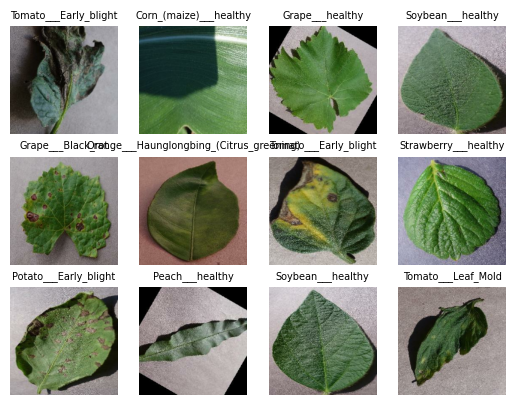

In [7]:
for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]], fontdict={"size":7})
        plt.axis("off")
        
    plt.show()

# Model building

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Rescaling, GlobalAveragePooling2D

# Models


In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255, input_shape=(200,200,3)),

    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(32, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(64, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.3),

    # Block 3
    tf.keras.layers.Conv2D(128, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(128, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.4),

    # Block 4
    tf.keras.layers.Conv2D(256, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 200, 200, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 100, 100, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 100, 100, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 50, 50, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 50, 50, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 25, 25, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 114,662 (447.90 KB)

 Trainable params: 114,662 (447.90 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer="adam", loss = loss, metrics=["accuracy"])

In [ ]:
history = model.fit(train_ds,
                    epochs=20, 
                    validation_data=val_ds, 
                    callbacks = callbacks
                   )

Epoch 1/20
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.1965 - loss: 2.8804

In [ ]:
loss, accuracy = model.evaluate(test_ds)

In [ ]:
loss, accuracy

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["accuracy"])

# Saving Model

In [7]:
import joblib
import numpy as np

In [ ]:
joblib.dump(model,"C:/Users/PAWAN/mega project/Model (pkl)/plant_disease_detection.pkl")

In [ ]:
from keras.models import save_model
save_model(model,"C:/Users/PAWAN/mega project/Model (pkl)/plant_disease_detection.h5")

# Saving List (class_names)

In [ ]:
joblib.dump(class_names,"C:/Users/PAWAN/mega project/Model (pkl)/class_names.pkl")

## Testing

In [3]:
class_names = joblib.load("C:/Users/PAWAN/mega project/Model (pkl)/class_names.pkl")
model = joblib.load("C:/Users/PAWAN/mega project/Model (pkl)/plant_disease_detection.pkl")

In [8]:

import random
import glob

paths = glob.glob(r"C:\Users\PAWAN\mega project\Plants Disease Dectection\archive (5)\test\test\*.JPG")
n = random.randint(0,len(paths))
print(f"path: {paths[n]}")

test_img = keras.utils.load_img(paths[n]
                                ,target_size=(128,128,3))
arr_img = keras.utils.img_to_array(test_img)
arr_img = tf.expand_dims(arr_img, axis=0)

prediction = model.predict(arr_img)

index = np.argmax(prediction)

print(f"prediction: {class_names[index]}")

path: C:\Users\PAWAN\mega project\Plants Disease Dectection\archive (5)\test\test\TomatoYellowCurlVirus2.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
prediction: Tomato___Tomato_Yellow_Leaf_Curl_Virus
